# Indian Pines — EDA

In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')

## Завантаження даних

In [2]:
mat = sio.loadmat('data/IP/Indian_pines_corrected.mat')
X = mat['indian_pines_corrected'].astype(np.float32)  # (145, 145, 200)
y = np.load('data/IP/IPgt.npy').astype(np.int32)       # (145, 145)

print('Куб даних X:', X.shape, '  dtype:', X.dtype)
print('Ground truth y:', y.shape, '  dtype:', y.dtype)

Куб даних X: (145, 145, 200)   dtype: float32
Ground truth y: (145, 145)   dtype: int32


## Базові параметри

In [7]:
H, W, C = X.shape
n_classes = len(np.unique(y)) - 1  # без фону (0)
total_pixels = H * W
labeled_pixels = np.sum(y > 0)
background_pixels = np.sum(y == 0)

print(f'Розміри сцени:       {H} x {W} пікселів')
print(f'Кількість каналів:   {C}')
print(f'Кількість класів:    {n_classes}')
print(f'Всього пікселів:     {total_pixels}')
print(f'Розмічених (не фон): {labeled_pixels} ({labeled_pixels/total_pixels*100:.1f}%)')
print(f'Фон (клас 0):        {background_pixels} ({background_pixels/total_pixels*100:.1f}%)')

Розміри сцени:       145 x 145 пікселів
Кількість каналів:   200
Кількість класів:    16
Всього пікселів:     21025
Розмічених (не фон): 10249 (48.7%)
Фон (клас 0):        10776 (51.3%)


## Розподіл класів

In [8]:
CLASS_NAMES = {
    1:  'Alfalfa',
    2:  'Corn-notill',
    3:  'Corn-mintill',
    4:  'Corn',
    5:  'Grass-pasture',
    6:  'Grass-trees',
    7:  'Grass-pasture-mowed',
    8:  'Hay-windrowed',
    9:  'Oats',
    10: 'Soybean-notill',
    11: 'Soybean-mintill',
    12: 'Soybean-clean',
    13: 'Wheat',
    14: 'Woods',
    15: 'Buildings-Grass-Trees-Drives',
    16: 'Stone-Steel-Towers',
}

counts = {cls: int(np.sum(y == cls)) for cls in range(1, 17)}
print(f'{'Клас':>4}  {'Назва':<35} {'Кількість':>10}  {'%':>6}')
print('-' * 62)
for cls, cnt in counts.items():
    print(f'{cls:>4}  {CLASS_NAMES[cls]:<35} {cnt:>10}  {cnt/labeled_pixels*100:>6.2f}%')

values = list(counts.values())
mode_cls = max(counts, key=counts.get)
min_cls  = min(counts, key=counts.get)
print(f'\nМода (найбільший клас): {mode_cls} — {CLASS_NAMES[mode_cls]} ({counts[mode_cls]} px)')
print(f'Мінімальний клас:       {min_cls} — {CLASS_NAMES[min_cls]} ({counts[min_cls]} px)')
print(f'Середнє по класах:      {np.mean(values):.1f} px')
print(f'Медіана по класах:      {np.median(values):.1f} px')

Клас  Назва                                Кількість       %
--------------------------------------------------------------
   1  Alfalfa                                     46    0.45%
   2  Corn-notill                               1428   13.93%
   3  Corn-mintill                               830    8.10%
   4  Corn                                       237    2.31%
   5  Grass-pasture                              483    4.71%
   6  Grass-trees                                730    7.12%
   7  Grass-pasture-mowed                         28    0.27%
   8  Hay-windrowed                              478    4.66%
   9  Oats                                        20    0.20%
  10  Soybean-notill                             972    9.48%
  11  Soybean-mintill                           2455   23.95%
  12  Soybean-clean                              593    5.79%
  13  Wheat                                      205    2.00%
  14  Woods                                     1265   12.34%
  15  Bu

/var/folders/zq/0x5njn3506d3dlhny38q9tfm0000gn/T/ipykernel_34275/603083430.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CLASS_NAMES[c] for c in counts], rotation=45, ha='right', fontsize=8)


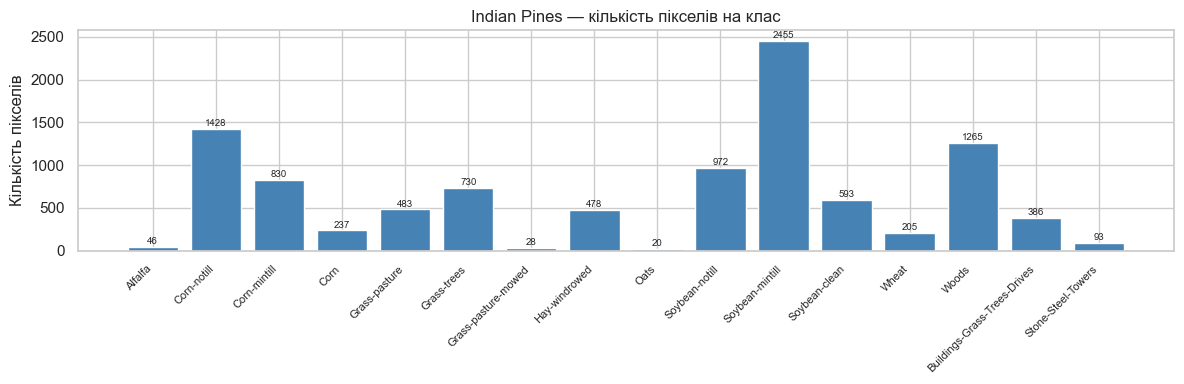

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar([CLASS_NAMES[c] for c in counts], counts.values(), color='steelblue', edgecolor='white')
ax.set_title('Indian Pines — кількість пікселів на клас')
ax.set_ylabel('Кількість пікселів')
ax.set_xticklabels([CLASS_NAMES[c] for c in counts], rotation=45, ha='right', fontsize=8)
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(v), ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

## Спектральні характеристики

Глобальні статистики по спектральних каналах:
  Min:  955.0000
  Max:  9604.0000
  Mean: 2652.3889
  Std:  1592.3401


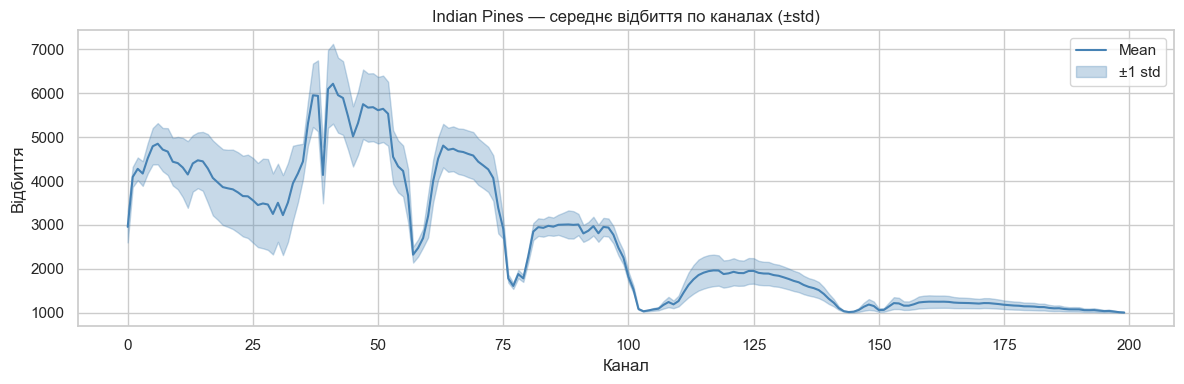

In [10]:
X_flat = X.reshape(-1, C)  # (21025, 200)
print('Глобальні статистики по спектральних каналах:')
print(f'  Min:  {X_flat.min():.4f}')
print(f'  Max:  {X_flat.max():.4f}')
print(f'  Mean: {X_flat.mean():.4f}')
print(f'  Std:  {X_flat.std():.4f}')

channel_means = X_flat.mean(axis=0)
channel_stds  = X_flat.std(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(channel_means, label='Mean', color='steelblue')
ax.fill_between(range(C), channel_means - channel_stds, channel_means + channel_stds,
                alpha=0.3, color='steelblue', label='±1 std')
ax.set_title('Indian Pines — середнє відбиття по каналах (±std)')
ax.set_xlabel('Канал')
ax.set_ylabel('Відбиття')
ax.legend()
plt.tight_layout()
plt.show()

## Ground truth map

/var/folders/zq/0x5njn3506d3dlhny38q9tfm0000gn/T/ipykernel_34275/1499049458.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', 17)


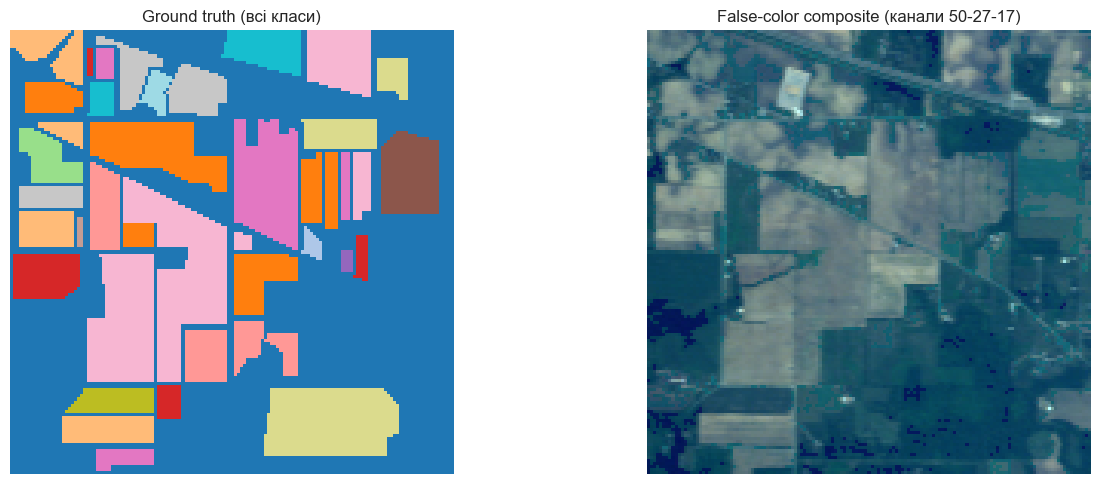

In [12]:
cmap = plt.cm.get_cmap('tab20', 17)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(y, cmap=cmap, vmin=0, vmax=16)
axes[0].set_title('Ground truth (всі класи)')
axes[0].axis('off')

# RGB composit з каналів 50, 27, 17 (приблизно R,G,B для AVIRIS)
rgb = X[:, :, [26, 15, 5]]
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
axes[1].imshow(rgb)
axes[1].set_title('False-color composite (канали 50-27-17)')
axes[1].axis('off')

plt.tight_layout()
plt.show()